In [ ]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/pmos4.mat')
nmos4 = lk('lookup_table/nmos4.mat')
#20H17

## LDO regulator
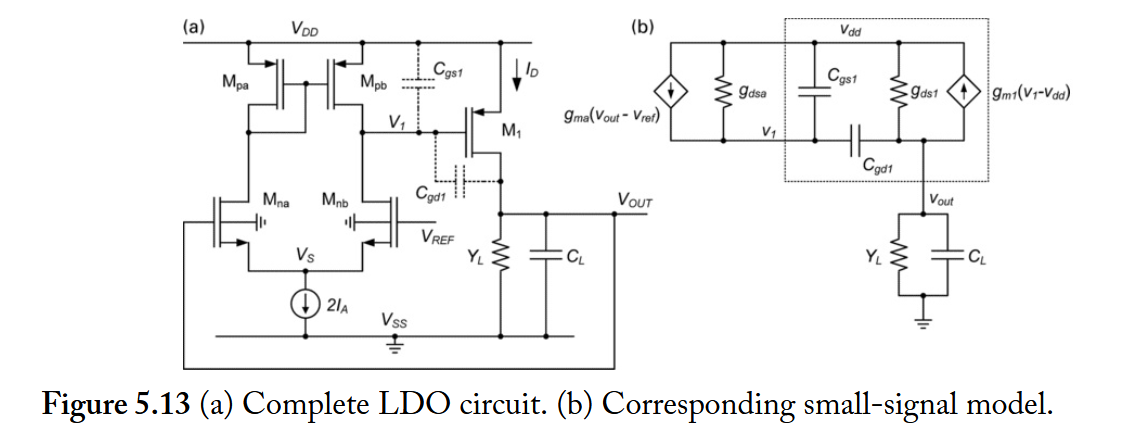 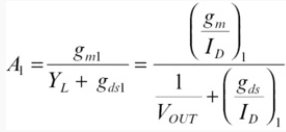  
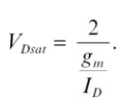

In [ ]:
#Spec
VDD = 2.7
Vout = VDD-0.3
Iout = 10e-3
Lballast = 0.35
Lpmirror = 0.5
Ln = 0.5

In [19]:
VDS_M1 = VDD - Vout
#Size M1
#Vdsat < 300mV => 2/(gm_id1) < 300mV
#gm_id1 >= 2 / 0.3
gm_id1 = 10
#gm_id1 = np.linspace(5,25,10)
JD1 = pmos4.lookup('ID_W', GM_ID = gm_id1, VDS = VDS_M1, L=Lballast)
W1 = Iout / JD1

#Compute low freq gain
gds_id1 = pmos4.lookup('GDS_ID', GM_ID = gm_id1, VDS = VDS_M1, L=Lballast)
A1 = gm_id1 / (1/Vout + gds_id1)

#Additionnal cap 
cgs1 = pmos4.lookup('CGS_W', GM_ID = gm_id1, VDS = VDS_M1, L=Lballast) * W1
cgd1 = pmos4.lookup('CGD_W', GM_ID = gm_id1, VDS = VDS_M1, L=Lballast) * W1

W1


np.float64(5566.924649827298)

Diff gain  
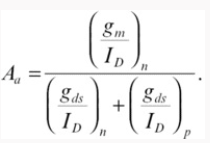

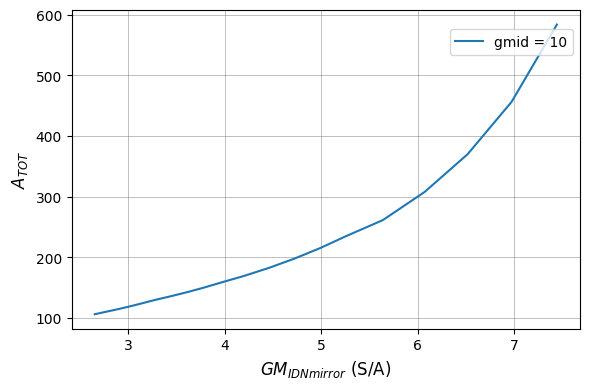

In [20]:
##Compute GDS_ID Mirroir P from what we know
VGS_M1 = pmos4.lookupVGS(GM_ID=gm_id1, VDS = VDS_M1, L=Lballast)
vd_mirror_P  = VDD - VGS_M1; 
gds_id_pmirror = pmos4.lookup('GDS_ID', VGS=VGS_M1, VDS=VGS_M1,L=Lpmirror)

##Compute Mirror M
##What we want VDS_Ndiffpair 
##WHat we know :
VDS_Pmirror = VGS_M1
VD_Ndiffpair = VDD - VDS_Pmirror
#VS ? 
#VS = Vout - VGS_Ndiffpair
Vs = np.linspace(1, 1.4, 20)
Adiff = []
gm_id_nmirror = []
for k in range(len(Vs)):
    #print(k)
    _gm_id_nmirror = nmos4.lookup('GM_ID', VGS = Vout- Vs[k], VDS = VD_Ndiffpair - Vs[k], VSB = -Vs[k], L=Ln)
    gds_id_nmirror = nmos4.lookup('GDS_ID', VGS = Vout- Vs[k], VDS = VD_Ndiffpair - Vs[k], VSB = -Vs[k], L=Ln)
    Adiff.append(_gm_id_nmirror / (gds_id_nmirror + gds_id_pmirror))
    gm_id_nmirror.append(_gm_id_nmirror)

A_tot = np.multiply(A1,Adiff)

fig,ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(gm_id_nmirror, A_tot, linewidth=1.5, label=f"gmid = {gm_id1}")
ax1.set_xlabel('$GM_{IDNmirror}$ (S/A)', fontsize=12)
ax1.set_ylabel('$A_{TOT}$', fontsize=12)
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax1.legend(loc='center right', bbox_to_anchor=(1, 0.9))
plt.tight_layout()
plt.show()

In [24]:
##Je prend VS = 0.5 suivant le plot en haut
Vs = 0.7
##MOS L W
Id_amp = Iout * 0.02
Jdpmirror = pmos4.lookup('ID_W', VGS=VGS_M1, VDS=VGS_M1, L=Lpmirror)
Wp = Id_amp / Jdpmirror
Jdndiffpair = nmos4.lookup('ID_W', VGS = Vout - Vs, VDS = VD_Ndiffpair - Vs, VSB = -Vs, L=Ln)
Wn = Id_amp / Jdndiffpair
gm_id_n_diffpair = nmos4.lookup('GM_ID', VGS = Vout- Vs, VDS = VD_Ndiffpair - Vs, VSB = -Vs, L=Ln)
gds_id_n_diffpair = nmos4.lookup('GDS_ID', VGS = Vout- Vs, VDS = VD_Ndiffpair - Vs, VSB = -Vs, L=Ln)
gm_id_p_mirror = pmos4.lookup('GM_ID', VGS=VGS_M1, VDS=VGS_M1,L=Lpmirror)
gds_id_p_mirror = pmos4.lookup('GDS_ID', VGS=VGS_M1, VDS=VGS_M1,L=Lpmirror)

###PSR
gds_gds1 = pmos4.lookup('GM_GDS', GM_ID = gm_id1, VDS = VDS_M1, L=Lballast)
Aa = gm_id_n_diffpair / (gds_id_n_diffpair+gds_id_p_mirror)
PSR = gds_gds1 * Aa
Atot = Aa * A1

print('W_ballast = %.2F um' % (W1))
print('Wn = %.2F um' % (Wn))
print('Wp = %.2F um' % (Wp))
print('L_Ballast = %.2F um' % (Lballast))
print('L_nmos = %.2F um' % (Ln))
print('L_pmos = %.2F um' % (Lpmirror))
print('Id_amp = %.2F uA' % (Id_amp*1e6))
print('I_load_max = %.2F mA' % (Iout*1e3))
print('gm_id_p_ballast = %.2F ' % (gm_id1))
print('gm_id_p_mirror = %.2F ' % (gm_id_p_mirror))
print('gm_id_n_diffpair= %.2F ' % (gm_id_n_diffpair))
print('PSR= %.2F ' % (PSR))
print('Atot= %.2F ' % (Atot))
print('Vs= %.2F ' % (Vs))


W_ballast = 5566.92 um
Wn = 2.27 um
Wp = 147.88 um
L_Ballast = 0.35 um
L_nmos = 0.50 um
L_pmos = 0.50 um
Id_amp = 200.00 uA
I_load_max = 10.00 mA
gm_id_p_ballast = 10.00 
gm_id_p_mirror = 10.67 
gm_id_n_diffpair= 1.66 
PSR= 132.77 
Atot= 71.01 
Vs= 0.70 


## Exemple : W required versus Vout  
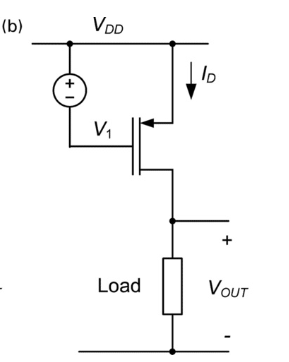

In [29]:
VDD = 2.7
I = 10e-3
L = 0.35
gmid = np.linspace(5, 25, 5)

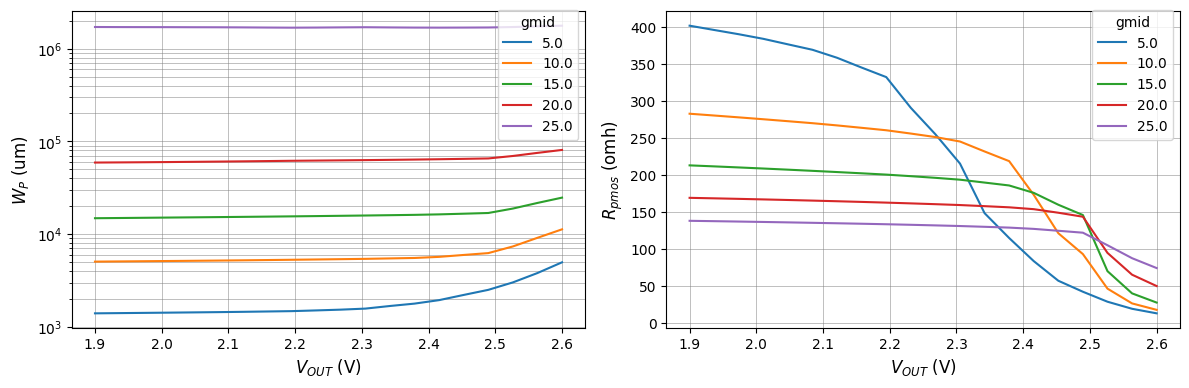

In [30]:
###Exemple pour voir l'effet du W &  gmid sur le dropout
Vdropout = np.linspace(0.1, 0.8, 20) #VDS

JD = pmos4.lookup('ID_W', GM_ID = gmid, VDS = Vdropout, VSB = 0, L = L)
Wp = I / JD
rp = 1 / (Wp * pmos4.lookup('GDS_W', GM_ID = gmid, VDS = Vdropout, VSB = 0, L = L))

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 4))
ax1.semilogy(VDD-Vdropout, Wp, linewidth=1.5, label=f"gmid = {gmid}")
ax1.set_xlabel('$V_{OUT}$ (V)', fontsize=12)
ax1.set_ylabel('$W_{P}$ (um)', fontsize=12)
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax1.legend(loc='center right', bbox_to_anchor=(1, 0.8), title='gmid', labels=gmid.tolist())
ax2.plot(VDD-Vdropout, rp, linewidth=1.5, label=f"gmid = {gmid}")
ax2.set_xlabel('$V_{OUT}$ (V)', fontsize=12)
ax2.set_ylabel('$R_{pmos}$ (omh)', fontsize=12)
ax2.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax2.legend(loc='center right', bbox_to_anchor=(1, 0.8), title='gmid', labels=gmid.tolist())
plt.tight_layout()
plt.show()

